SECTION 0 


In [2]:
# Section 0 — Setup
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import roc_curve, auc
 
sys.path.insert(0, str(Path.cwd().parent))
 
from src.config import TRAIN_TEST_DIR, TARGET_COLS, FIGURES_DIR, TABLES_DIR, MODELS_DIR
from src.model import (
    build_logistic_baseline, build_rf_baseline, build_xgb_single,
    build_mltp, build_lgbm_mltp, load_class_weights, save_model, load_model,
)
from src.evaluation import (
    evaluate_single_label, evaluate_multilabel,
    build_benchmark_table, print_benchmark,
)
from src.logger import get_console_logger
from src.utils import timer
 
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.figsize': (12, 4), 'savefig.dpi': 150})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
log = get_console_logger('02_modeling')
print('Setup complete')
 


Setup complete


In [3]:
# Load train/test splits
X_train = pd.read_csv(TRAIN_TEST_DIR / 'X_train.csv')
X_test  = pd.read_csv(TRAIN_TEST_DIR / 'X_test.csv')
y_train = pd.read_csv(TRAIN_TEST_DIR / 'y_train.csv')
y_test  = pd.read_csv(TRAIN_TEST_DIR / 'y_test.csv')
class_weights = load_class_weights()
 
print(f'X_train: {X_train.shape}  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  y_test: {y_test.shape}')
print(f'Class weights: {class_weights}')
print(f'Features: {list(X_train.columns)}')
 


2026-05-12 16:20:04  INFO      src.model: Class weights loaded: {'stunted': 1.8195, 'underweight': 2.2367, 'wasted': 4.3705}
X_train: (159036, 11)  X_test: (39760, 11)
y_train: (159036, 3)  y_test: (39760, 3)
Class weights: {'stunted': 1.8195, 'underweight': 2.2367, 'wasted': 4.3705}
Features: ['v024', 'v025', 'v106', 'v130', 'b4', 'm4', 'm19', 'h11', 'hw1', 'hw2', 'hw3']


SECTION 1 — Train Baselines

In [4]:
# Section 1 — Train all baselines
# Stores fitted models and metrics in dictionaries for later comparison.
fitted_models: dict = {}
all_results:   dict = {}
 
BUILDERS = {
    'logistic':     lambda lbl: build_logistic_baseline(X_train),
    'random_forest':lambda lbl: build_rf_baseline(X_train),
    'xgb_single':   lambda lbl: build_xgb_single(X_train, class_weights.get(lbl, 2.0)),
}
 
for model_name, builder in BUILDERS.items():
    label_results = {}
    for label in TARGET_COLS:
        y_tr = y_train[label].dropna().astype(int)
        X_tr = X_train.loc[y_tr.index]
        pipe = builder(label)
        pipe.fit(X_tr, y_tr)
        fitted_models[f'{model_name}_{label}'] = pipe
        label_results[label] = evaluate_single_label(pipe, X_test, y_test[label], label)
    all_results[model_name] = label_results
    print(f'Trained: {model_name}')
 
print('All baselines trained')
 


2026-05-12 16:20:38  INFO      src.evaluation: stunted: recall=0.845 f1=0.791 roc_auc=0.922
2026-05-12 16:20:39  INFO      src.evaluation: underweight: recall=0.924 f1=0.849 roc_auc=0.962
2026-05-12 16:20:39  INFO      src.evaluation: wasted: recall=0.975 f1=0.899 roc_auc=0.995
Trained: logistic
2026-05-12 16:21:05  INFO      src.evaluation: stunted: recall=0.961 f1=0.908 roc_auc=0.987
2026-05-12 16:21:27  INFO      src.evaluation: underweight: recall=0.959 f1=0.867 roc_auc=0.986
2026-05-12 16:21:49  INFO      src.evaluation: wasted: recall=0.987 f1=0.837 roc_auc=0.994
Trained: random_forest
2026-05-12 16:21:52  INFO      src.evaluation: stunted: recall=0.982 f1=0.970 roc_auc=0.999
2026-05-12 16:21:57  INFO      src.evaluation: underweight: recall=0.988 f1=0.969 roc_auc=0.999
2026-05-12 16:22:03  INFO      src.evaluation: wasted: recall=0.997 f1=0.958 roc_auc=0.999
Trained: xgb_single
All baselines trained


In [5]:
# Section 1 — Train MLTP (XGBoost + LightGBM)
with timer('MLTP XGBoost fit'):
    mltp_xgb = build_mltp(X_train, class_weights)
    mltp_xgb.fit(X_train, y_train[TARGET_COLS].fillna(0).astype(int))
fitted_models['mltp_xgb'] = mltp_xgb
all_results['mltp_xgb'] = evaluate_multilabel(mltp_xgb, X_test, y_test[TARGET_COLS])
print('MLTP XGBoost trained')
 
with timer('MLTP LightGBM fit'):
    mltp_lgbm = build_lgbm_mltp(X_train, class_weights)
    mltp_lgbm.fit(X_train, y_train[TARGET_COLS].fillna(0).astype(int))
fitted_models['mltp_lgbm'] = mltp_lgbm
all_results['mltp_lgbm'] = evaluate_multilabel(mltp_lgbm, X_test, y_test[TARGET_COLS])
print('MLTP LightGBM trained')


2026-05-12 16:22:27  INFO      src.evaluation: stunted: recall=0.992 f1=0.965 roc_auc=0.998
2026-05-12 16:22:27  INFO      src.evaluation: underweight: recall=0.992 f1=0.964 roc_auc=0.999
2026-05-12 16:22:27  INFO      src.evaluation: wasted: recall=0.991 f1=0.963 roc_auc=0.999
2026-05-12 16:22:27  INFO      src.evaluation: Macro avg: recall=0.992
MLTP XGBoost trained
2026-05-12 16:23:07  INFO      src.evaluation: stunted: recall=0.987 f1=0.968 roc_auc=0.999
2026-05-12 16:23:07  INFO      src.evaluation: underweight: recall=0.986 f1=0.969 roc_auc=0.999
2026-05-12 16:23:07  INFO      src.evaluation: wasted: recall=0.989 f1=0.973 roc_auc=1.000
2026-05-12 16:23:07  INFO      src.evaluation: Macro avg: recall=0.987
MLTP LightGBM trained


In [6]:
# Save the primary MLTP model
save_model(mltp_xgb, 'mltp_xgb_v1')
print(f'MLTP saved: models/mltp_xgb_v1.pkl')
 


2026-05-12 16:23:07  INFO      src.model: Model saved: /workspaces/malnutrisense/models/mltp_xgb_v1.pkl  (5.1 MB)
MLTP saved: models/mltp_xgb_v1.pkl


SECTION 2 — Benchmark Table

In [7]:
# Section 2 — Benchmark comparison table
benchmark = build_benchmark_table(all_results)
print_benchmark(benchmark)
 
# Pivot: models as rows, labels as columns, values = recall
pivot_recall = benchmark.pivot(index='model', columns='label', values='recall')
pivot_recall['macro_recall'] = pivot_recall.mean(axis=1)
pivot_recall = pivot_recall.sort_values('macro_recall', ascending=False)
display(pivot_recall.style.format('{:.3f}').background_gradient(cmap='Greens', axis=None))
 



Benchmark Comparison (sorted by Recall per label):
Model                  Label            Recall       F1   ROC-AUC  Precision
---------------------------------------------------------------------------
mltp_xgb               stunted           0.992    0.965     0.999      0.940
mltp_lgbm              stunted           0.987    0.968     0.999      0.951
xgb_single             stunted           0.982    0.970     0.999      0.958
random_forest          stunted           0.961    0.908     0.987      0.861
logistic               stunted           0.845    0.791     0.922      0.743
mltp_xgb               underweight       0.992    0.964     0.999      0.937
xgb_single             underweight       0.988    0.969     0.999      0.952
mltp_lgbm              underweight       0.986    0.969     0.999      0.952
random_forest          underweight       0.959    0.867     0.986      0.791
logistic               underweight       0.924    0.849     0.962      0.785
xgb_single             wa

label,stunted,underweight,wasted,macro_recall
model,,,,
mltp_xgb,0.992,0.992,0.991,0.992
xgb_single,0.982,0.988,0.997,0.989
mltp_lgbm,0.987,0.986,0.989,0.987
random_forest,0.961,0.959,0.987,0.969
logistic,0.845,0.924,0.975,0.915


2026-05-12 16:23:44  INFO      src.evaluation: Benchmark saved: /workspaces/malnutrisense/reports/tables/full_benchmark.csv


/tmp/ipykernel_5478/583516492.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_data['model'], rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_5478/583516492.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_data['model'], rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_5478/583516492.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_data['model'], rotation=30, ha='right', fontsize=9)


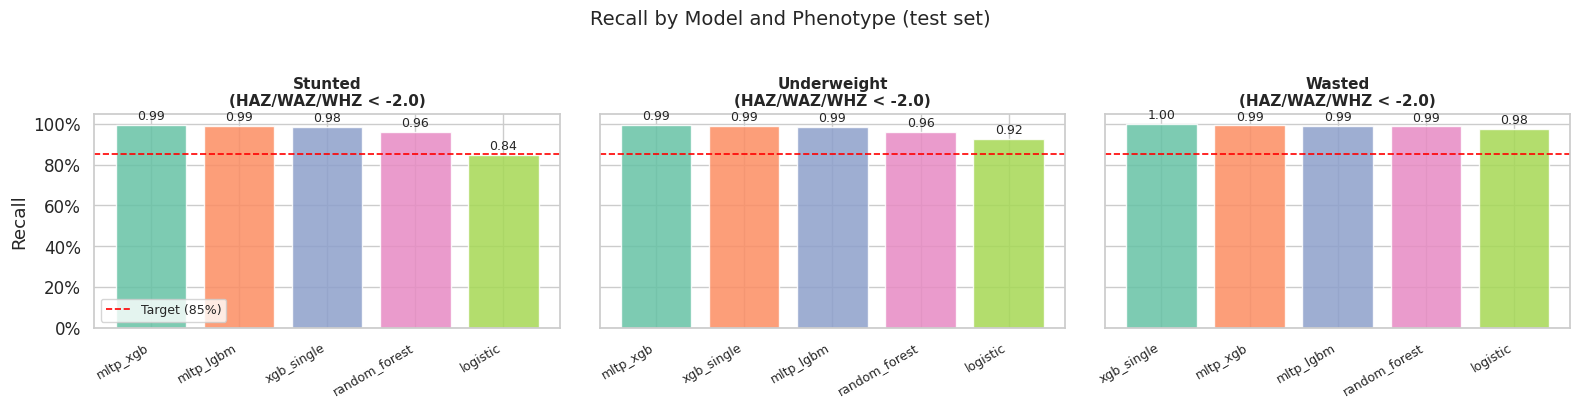

Saved: /workspaces/malnutrisense/reports/figures/recall_by_model.png


In [8]:
# Save benchmark CSV
from src.evaluation import save_benchmark
save_benchmark(benchmark, 'full_benchmark')
 
# Grouped bar chart: Recall per label by model
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
colors = plt.cm.Set2.colors
 
for ax, label in zip(axes, TARGET_COLS):
    label_data = benchmark[benchmark['label']==label].copy()
    label_data = label_data.sort_values('recall', ascending=False)
    bars = ax.bar(label_data['model'], label_data['recall'],
                  color=colors[:len(label_data)], alpha=0.85, edgecolor='white')
    ax.set_title(f'{label.capitalize()}\n(HAZ/WAZ/WHZ < -2.0)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Recall' if ax == axes[0] else '')
    ax.set_xticklabels(label_data['model'], rotation=30, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
    ax.axhline(0.85, color='red', linewidth=1.2, linestyle='--', label='Target (85%)')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
 
axes[0].legend(fontsize=9)
plt.suptitle('Recall by Model and Phenotype (test set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'recall_by_model.png')
plt.show()
print(f'Saved: {FIGURES_DIR}/recall_by_model.png')
 


SECTION 3 — ROC Curves

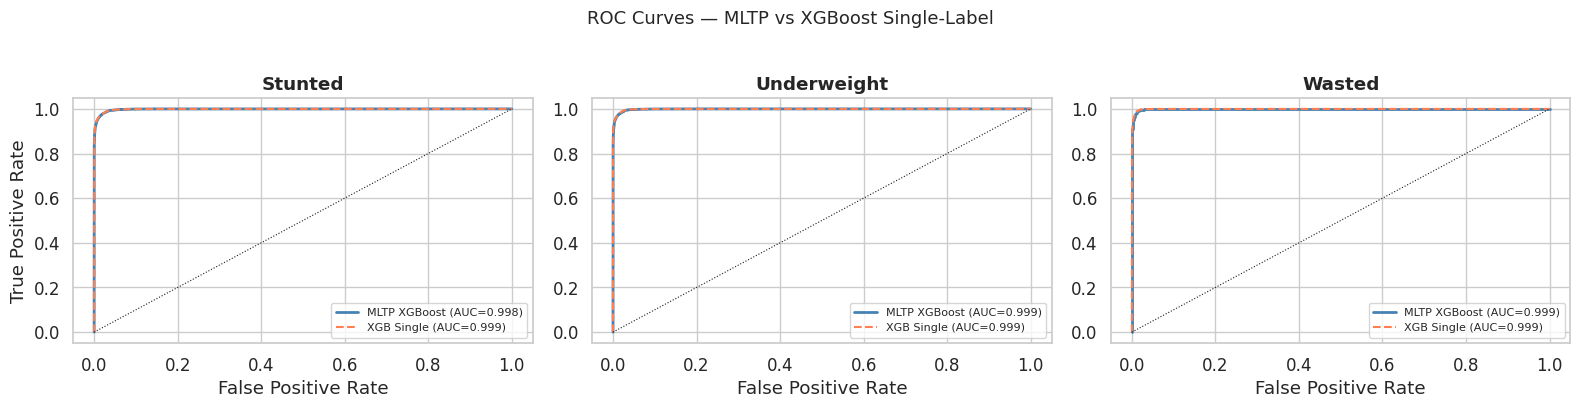

Saved: /workspaces/malnutrisense/reports/figures/roc_curves.png


In [9]:
# Section 3 — ROC curves for MLTP vs best single-label baseline
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
proba_mltp = mltp_xgb.predict_proba(X_test)
 
for ax, (i, label) in zip(axes, enumerate(TARGET_COLS)):
    y_true = y_test[label].dropna().astype(int)
    mask   = y_test[label].notna()
 
    # MLTP ROC
    fpr_m, tpr_m, _ = roc_curve(y_true, proba_mltp[i][mask, 1])
    auc_m = auc(fpr_m, tpr_m)
    ax.plot(fpr_m, tpr_m, lw=2, label=f'MLTP XGBoost (AUC={auc_m:.3f})', color='steelblue')
 
    # Best single-label baseline ROC (xgb_single)
    key = f'xgb_single_{label}'
    if key in fitted_models:
        p_xgb = fitted_models[key].predict_proba(X_test[mask])[:, 1]
        fpr_x, tpr_x, _ = roc_curve(y_true, p_xgb)
        auc_x = auc(fpr_x, tpr_x)
        ax.plot(fpr_x, tpr_x, lw=1.5, linestyle='--',
                label=f'XGB Single (AUC={auc_x:.3f})', color='coral')
 
    ax.plot([0,1],[0,1], 'k:', linewidth=0.8)
    ax.set_title(f'{label.capitalize()}', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate' if ax==axes[0] else '')
    ax.legend(fontsize=8)
 
plt.suptitle('ROC Curves — MLTP vs XGBoost Single-Label', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png')
plt.show()
print(f'Saved: {FIGURES_DIR}/roc_curves.png')
 


SECTION 4 — Summary Cell 

In [12]:
# Summary
figures = list(FIGURES_DIR.glob('*.png'))
print('='*55)
print('02_modeling.ipynb — Complete')
print('='*55)
print(f'Models trained: {len(fitted_models)}')
print(f'MLTP XGBoost macro recall: {all_results["mltp_xgb"]["macro_avg"]["recall"]:.3f}')
print(f'MLTP LightGBM macro recall: {all_results["mltp_lgbm"]["macro_avg"]["recall"]:.3f}')
print(f'Benchmark: reports/tables/full_benchmark.csv')
print(f'Figures: {len(figures)} in {FIGURES_DIR}')
print('Next: notebooks/03_shap_fairness.ipynb (Steps 25-27)')
print('='*55)
 


02_modeling.ipynb — Complete
Models trained: 11
MLTP XGBoost macro recall: 0.992
MLTP LightGBM macro recall: 0.987
Benchmark: reports/tables/full_benchmark.csv
Figures: 6 in /workspaces/malnutrisense/reports/figures
Next: notebooks/03_shap_fairness.ipynb (Steps 25-27)
